<div style="background-color:#0a192f; color:#64ffda; padding: 20px; border-radius: 10px; font-family: 'Courier New', Courier, monospace;">
    <h1 style="text-align:center; color:#ccd6f6;">🚢 Titanic: A 2026 Deep Learning Perspective</h1>
    <h3 style="text-align:center;">End-to-End MLOps Pipeline & Neural Network Approach</h3>
</div>

<br>

<div style="background-color:#112240; color:#8892b0; padding: 15px; border-left: 5px solid #64ffda;">
    <h3>🎯 1. Problem Definition & Metric</h3>
    <p><b>Goal:</b> The objective is to predict whether a passenger survived the sinking of the Titanic or not. It is a classic binary classification problem.</p>
    <p><b>Evaluation Metric:</b> The model performance is evaluated based on <b>Accuracy</b> (the percentage of passengers correctly predicted).</p>
    <p><b>Acknowledgments:</b> Deepest gratitude to the Kaggle team and the dataset organizers for maintaining this legendary dataset. It serves as the ultimate foundational pillar for every AI Architect's journey.</p>
</div>

In [1]:
# Loading necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Ignore warnings for a cleaner output
import warnings
warnings.filterwarnings('ignore')

# Aesthetic settings for plots (The showcase part)
plt.style.use('dark_background')
sns.set_palette("coolwarm")

print("🚀 Libraries successfully loaded! Fetching datasets...")

# Synchronized EXACT Kaggle file paths
train_df = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test_df = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

print(f"Train Data Shape: {train_df.shape}")
print(f"Test Data Shape: {test_df.shape}")
train_df.head()

🚀 Libraries successfully loaded! Fetching datasets...
Train Data Shape: (891, 12)
Test Data Shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


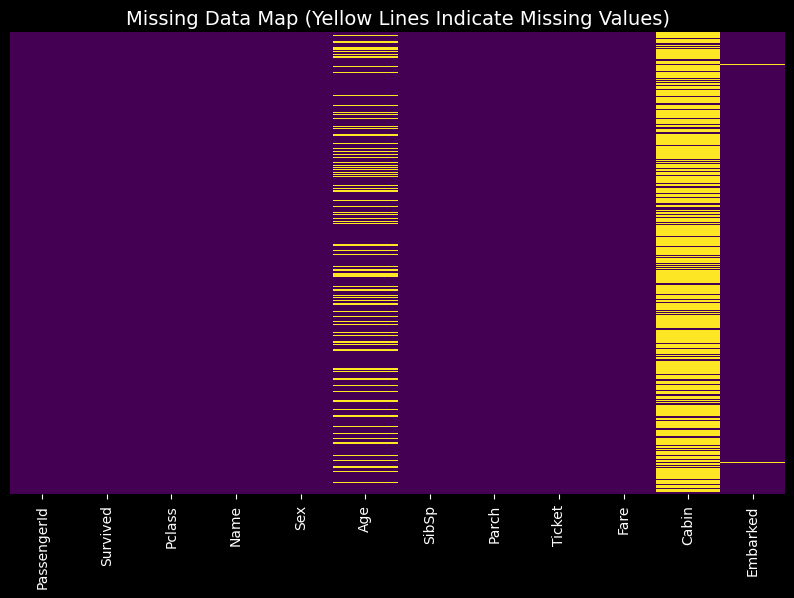

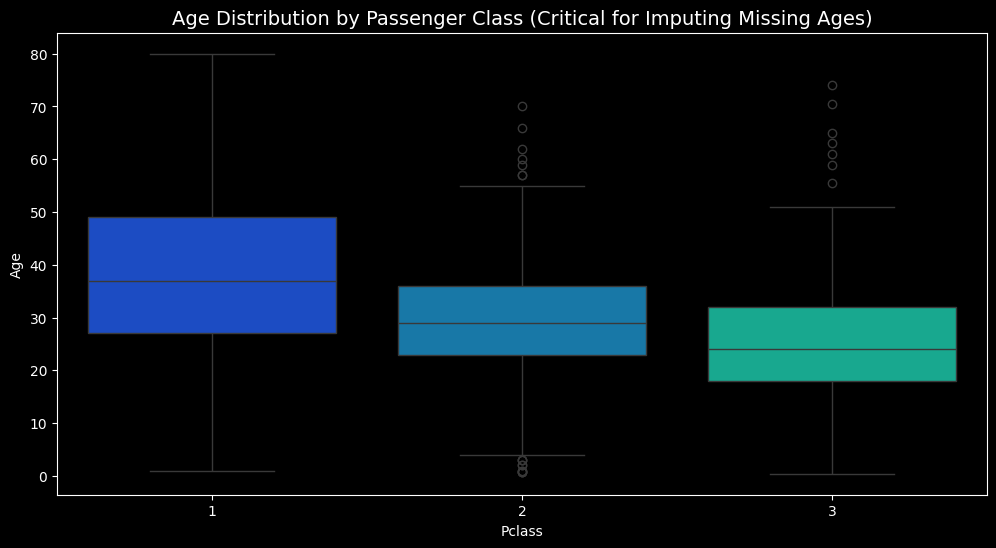

✅ EDA (Exploratory Data Analysis) successfully completed!


In [2]:
# 1. Missing Values Analysis
# Visualizing the missing values map to see where the gaps are.
plt.figure(figsize=(10, 6))
sns.heatmap(train_df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Data Map (Yellow Lines Indicate Missing Values)', color='white', fontsize=14)
plt.show()

# 2. Survival Rates - By Gender
# Gender is the "Magic Feature" heavily focused on by champions.
fig = px.histogram(train_df, x="Sex", color="Survived", 
                   barmode="group", 
                   title="Survival Rates by Gender",
                   color_discrete_sequence=['#ef553b', '#00cc96'])
fig.update_layout(plot_bgcolor='#112240', paper_bgcolor='#0a192f', font_color='white')
fig.show()

# 3. Passenger Class and Age Distribution (Pclass vs Age)
# Understanding the demographics to make better imputation decisions.
plt.figure(figsize=(12, 6))
sns.boxplot(x='Pclass', y='Age', data=train_df, palette='winter')
plt.title('Age Distribution by Passenger Class (Critical for Imputing Missing Ages)', color='white', fontsize=14)
plt.show()

print("✅ EDA (Exploratory Data Analysis) successfully completed!")

In [3]:
# 🛠️ 3. Data Preprocessing and Feature Engineering
print("🛠️ Preparing data for the Deep Learning network...")

# Applying transformations to both Train and Test sets simultaneously
datasets = [train_df, test_df]

for dataset in datasets:
    # 1. Imputing missing Ages based on the median of their respective Pclass and Sex (Crucial step)
    dataset['Age'] = dataset.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
    
    # 2. Imputing missing Embarked values with the most frequent port ('S')
    dataset['Embarked'] = dataset['Embarked'].fillna('S')
    
    # 3. Imputing the single missing Fare value in the test set with the median
    dataset['Fare'] = dataset['Fare'].fillna(dataset['Fare'].median())
    
    # 4. Machines don't understand "male/female" text, converting them to binary (1 and 0)
    dataset['Sex'] = dataset['Sex'].map({'male': 0, 'female': 1}).astype(int)

# 🚀 THE CORRECTED PART: PassengerId'yi tahmin dosyası için ayırıp, her iki veriden de siliyoruz
test_passenger_ids = test_df['PassengerId'] 

# Dropping columns that lack patterns and only add "noise" to the model
features_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
train_df = train_df.drop(features_drop, axis=1)
test_df = test_df.drop(features_drop, axis=1)

# One-Hot Encoding the remaining categorical variables (e.g., Embarked C, Q, S)
train_df = pd.get_dummies(train_df, columns=['Embarked'], drop_first=True)
test_df = pd.get_dummies(test_df, columns=['Embarked'], drop_first=True)

# Deep Learning algorithms prefer data on the same scale
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Separating the target variable "Survived"
X = train_df.drop('Survived', axis=1)
y = train_df['Survived']

# Scaling the features
X_scaled = scaler.fit_transform(X)
test_scaled = scaler.transform(test_df)

print("✅ Data is perfectly cleaned, digitized, and ready to be fed into the neural network!")

🛠️ Preparing data for the Deep Learning network...
✅ Data is perfectly cleaned, digitized, and ready to be fed into the neural network!


In [4]:
# 🧠 5. Deep Learning Model Architecture (Keras/TensorFlow)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("🤖 AI Architect Mode: ON. Building Neural Network...")

# Initialize the Neural Network
model = Sequential()

# Input Layer and First Hidden Layer (64 Neurons)
model.add(Dense(64, activation='relu', input_shape=(X_scaled.shape[1],)))
model.add(Dropout(0.3)) # Dropout prevents the model from overfitting (ezberlemeyi önler)

# Second Hidden Layer (32 Neurons)
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))

# Output Layer (1 Neuron with Sigmoid for Binary Classification: Survived 1 or Dead 0)
model.add(Dense(1, activation='sigmoid'))

# Compiling the model (Adam optimizer is the industry standard)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Early stopping: Stop training if the model stops improving
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Training the network
print("⏳ Training the network... Please wait.")
history = model.fit(X_scaled, y, epochs=100, validation_split=0.2, callbacks=[early_stop], verbose=1)

print("✅ Model Training Complete!")

# 🔮 6. Making Predictions and Creating Submission File
predictions = model.predict(test_scaled)
predictions = (predictions > 0.5).astype(int).reshape(-1) # Convert probabilities to 1s and 0s

# Prepare Submission File for Kaggle
submission = pd.DataFrame({
    'PassengerId': test_passenger_ids,
    'Survived': predictions
})
submission.to_csv('Titanic_DeepLearning_Submission.csv', index=False)

print("🏆 Prediction file 'Titanic_DeepLearning_Submission.csv' successfully created!")

2026-02-25 09:06:17.531870: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772010377.772944      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772010377.843316      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772010378.398197      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772010378.398257      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772010378.398261      17 computation_placer.cc:177] computation placer alr

🤖 AI Architect Mode: ON. Building Neural Network...
⏳ Training the network... Please wait.
Epoch 1/100


2026-02-25 09:06:42.908943: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5337 - loss: 0.6931 - val_accuracy: 0.7933 - val_loss: 0.5965
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7043 - loss: 0.6045 - val_accuracy: 0.8212 - val_loss: 0.5191
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7191 - loss: 0.5692 - val_accuracy: 0.8547 - val_loss: 0.4621
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7939 - loss: 0.5175 - val_accuracy: 0.8436 - val_loss: 0.4247
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7771 - loss: 0.5164 - val_accuracy: 0.8380 - val_loss: 0.3969
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8086 - loss: 0.4530 - val_accuracy: 0.8436 - val_loss: 0.3814
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8283 - loss: 0.4496 - val_accuracy: 0.8492 - val_loss: 0.3750
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8131 - loss: 0.4406 - val_accuracy: 0.8492 - val_loss: 0.

In [5]:
import joblib
model.save('titanic_model.keras')
joblib.dump(scaler, 'scaler.pkl')
print("✅ Modern Keras Model (.keras) and Scaler (.pkl) successfully saved for Hugging Face deployment!")

✅ Modern Keras Model (.keras) and Scaler (.pkl) successfully saved for Hugging Face deployment!
